In [1]:
import os
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import load_img_and_label

# EDA imagens e ROI

In [2]:
imgs_base_path = '/media/matheus/HD/DatasetsCCTA/ImageCAS/'
imgs_path = [int(f.split(".")[0]) for f in os.listdir(imgs_base_path) if 'img' in f]

NP_SEED = 42
np.random.seed(NP_SEED)
imgs_id = pd.Series(imgs_path).sample(n=100).tolist()

## KDE dos valores dos pixels nas imagens

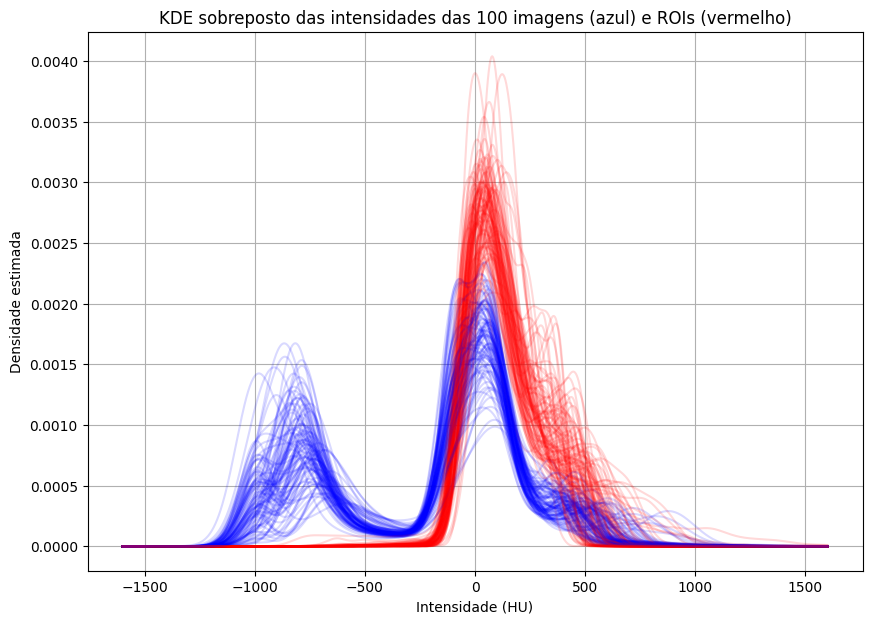

In [3]:
xs = np.linspace(-1600, 1600, 800)
plt.figure(figsize=(10, 7))

for img_id in imgs_id:
    img_path = f'{imgs_base_path}/{img_id}.img.nii.gz'
    label_path = img_path.replace('.img.nii.gz', '.label.nii.gz')
    img, mask = load_img_and_label(img_path, label_path)
    img_array = img.flatten()
    label_array = img[mask > 0].flatten()

    # Amostragem para evitar memory error
    vox_img = np.random.choice(img_array, min(10000, img_array.size), replace=False)
    vox_label = np.random.choice(label_array, min(10000, label_array.size), replace=False)

    kde_img = gaussian_kde(vox_img)
    kde_label = gaussian_kde(vox_label)

    ys_img = kde_img(xs)
    ys_label = kde_label(xs)

    plt.plot(xs, ys_img, color='blue', alpha=0.15)
    plt.plot(xs, ys_label, color='red', alpha=0.15)

plt.title('KDE sobreposto das intensidades das 100 imagens (azul) e ROIs (vermelho)')
plt.xlabel('Intensidade (HU)')
plt.ylabel('Densidade estimada')
plt.grid(True)
plt.show()

## KDE dos valores dos pixels em amostras de imagens

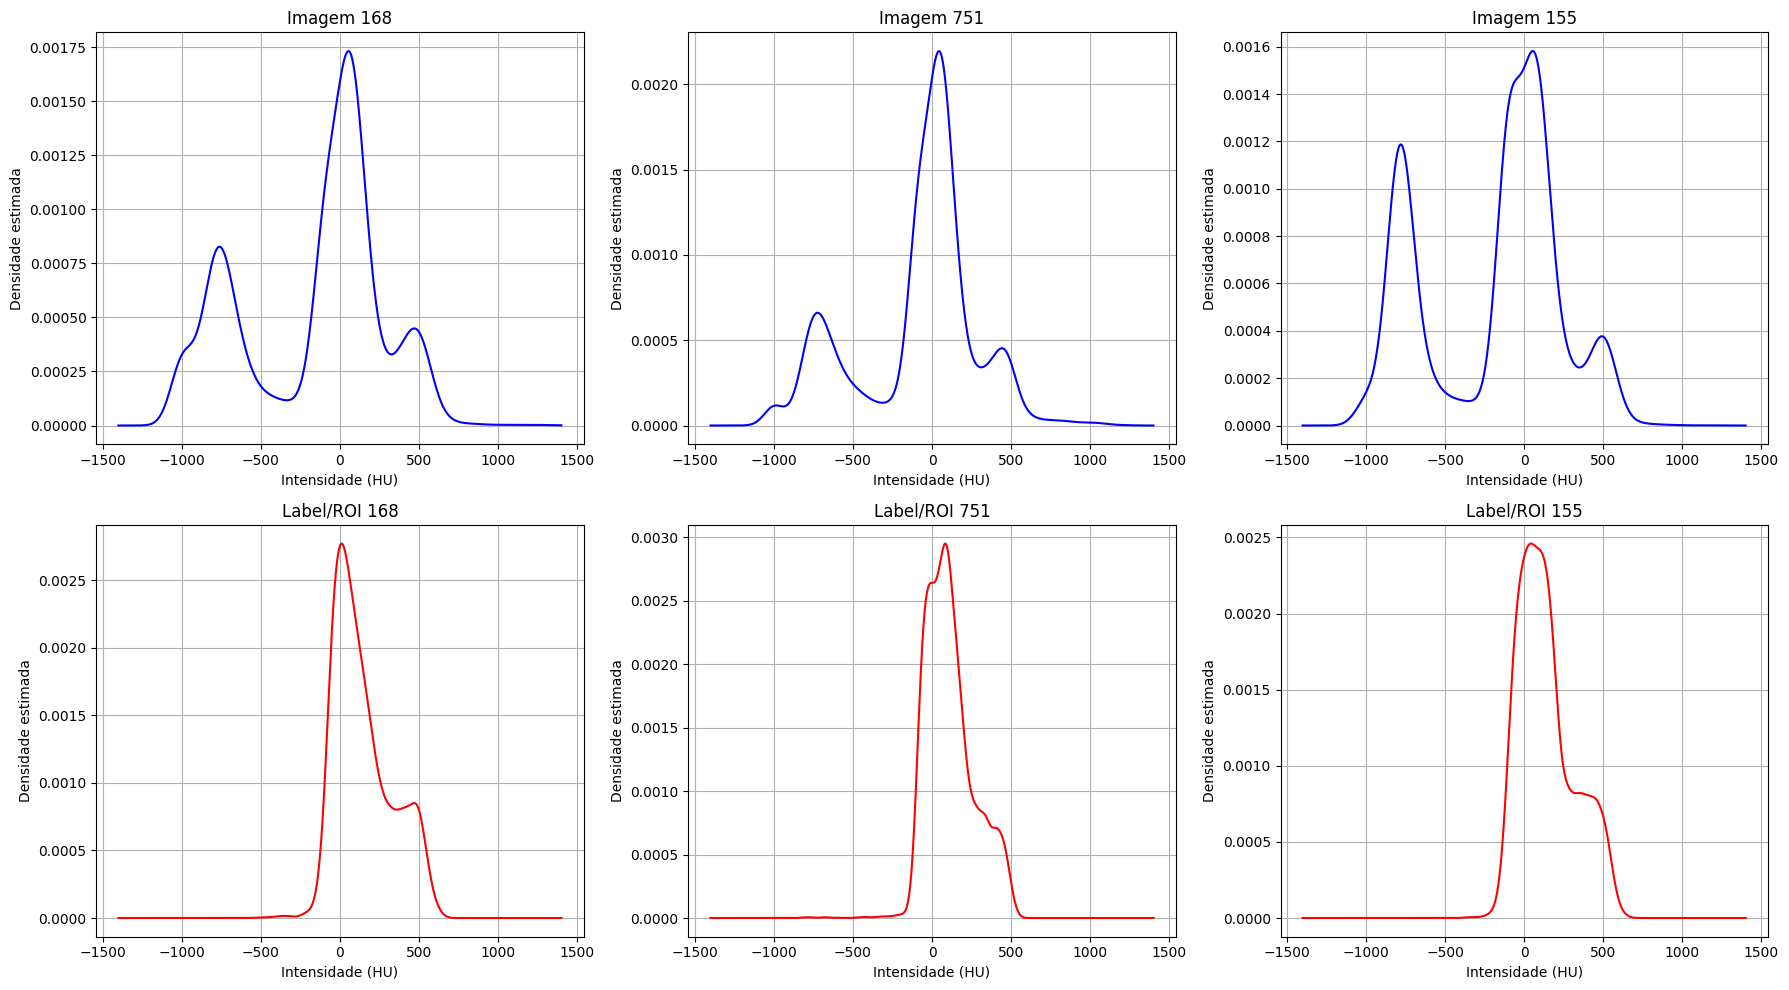

In [4]:
samples_id = pd.Series(imgs_id).sample(n=3).tolist()

fig, axes = plt.subplots(2, len(samples_id), figsize=(6 * len(samples_id), 10))
xs = np.linspace(-1400, 1400, 800)

for i, img_id in enumerate(samples_id):
    img_path = f'{imgs_base_path}/{img_id}.img.nii.gz'
    label_path = img_path.replace('.img.nii.gz', '.label.nii.gz')

    img, mask = load_img_and_label(img_path, label_path)
    label = img[mask > 0]
    img_array = img.flatten()
    label_array = label.flatten()

    # Amostragem para evitar memory error
    vox_img = np.random.choice(img_array, min(10000, img_array.size), replace=False)
    vox_label = np.random.choice(label_array, min(10000, label_array.size), replace=False)

    kde_img = gaussian_kde(vox_img)
    kde_label = gaussian_kde(vox_label)

    ys_img = kde_img(xs)
    ys_label = kde_label(xs)

    # Linha 0: imagem
    axes[0, i].plot(xs, ys_img, color='blue')
    axes[0, i].set_title(f'Imagem {img_id}')
    axes[0, i].set_xlabel("Intensidade (HU)")
    axes[0, i].set_ylabel("Densidade estimada")
    axes[0, i].grid(True)

    # Linha 1: label (ROI)
    axes[1, i].plot(xs, ys_label, color='red')
    axes[1, i].set_title(f'Label/ROI {img_id}')
    axes[1, i].set_xlabel("Intensidade (HU)")
    axes[1, i].set_ylabel("Densidade estimada")
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

## Análise de percentis para thresholding

In [5]:
min_hu = -2000
max_hu = 3000
bins = np.arange(min_hu, max_hu + 2) # +2 para incluir o max_hu como borda do último bin

# Inicializar histograma global
total_histogram = np.zeros(len(bins) - 1, dtype=np.int64)

for i, img_id in enumerate(imgs_id):
    try:
        img_path = f'{imgs_base_path}/{img_id}.img.nii.gz'
        label_path = img_path.replace('.img.nii.gz', '.label.nii.gz')

        # Carregar imagem
        img, mask = load_img_and_label(img_path, label_path)

        # Extrair voxels da ROI
        roi_voxels = img[mask > 0]

        # Ignorar imagens sem voxels na ROI
        if roi_voxels.size == 0:
            continue

        # Calcular histograma DESTA imagem
        counts, _ = np.histogram(roi_voxels, bins=bins)

        # Somar ao histograma GLOBAL
        total_histogram += counts

        # Liberar memória
        del img, mask, roi_voxels

    except Exception as e:
        print(f"Erro na imagem {img_id}: {e}")


# Agora, calcular os percentis e máximo absoluto a partir do histograma acumulado
cdf = np.cumsum(total_histogram)
total_voxels = cdf[-1]

# Função para encontrar percentil a partir do histograma acumulado
def get_percentile_from_hist(percentile, cdf, total, bins_edges):
    threshold_count = total * (percentile / 100.0)

    # Encontra o índice onde a soma acumulada ultrapassa o limiar
    idx = np.searchsorted(cdf, threshold_count)
    return bins_edges[idx]

# Calcular percentis desejados
p99 = get_percentile_from_hist(99, cdf, total_voxels, bins)
p99_5 = get_percentile_from_hist(99.5, cdf, total_voxels, bins)
p99_9 = get_percentile_from_hist(99.9, cdf, total_voxels, bins)

# Para o máximo absoluto, podemos ver o último bin que tem contagem > 0
nonzero_bins = np.nonzero(total_histogram)[0]
max_abs = bins[nonzero_bins[-1]] if len(nonzero_bins) > 0 else 0

print(f"\n--- Resultados da Análise Global (Total de voxels analisados: {total_voxels}) ---")
print(f"99.0% das artérias estão abaixo de: {p99} HU")
print(f"99.5% das artérias estão abaixo de: {p99_5} HU")
print(f"99.9% das artérias estão abaixo de: {p99_9} HU")
print(f"Máximo absoluto encontrado: {max_abs} HU")


--- Resultados da Análise Global (Total de voxels analisados: 11392118) ---
99.0% das artérias estão abaixo de: 658 HU
99.5% das artérias estão abaixo de: 737 HU
99.9% das artérias estão abaixo de: 946 HU
Máximo absoluto encontrado: 1958 HU
